# Functional Characterization of d' vs ISI Curves Across Model Hyperparameters

For every memory-model hyperparameter triple $\Theta_m = (\sigma_0, \sigma, \eta)$,
we compute d' at each ISI condition and fit an exponential decay:

$$d'(\text{ISI}) = A \, e^{-\lambda \, \text{ISI}} + C$$

This yields a **functional triple** $\theta_f = (A, \lambda, C)$ plus derived
summary statistics (avg d', $\Delta$d', R², etc.).

**Analysis strategy:** select a few representative $\sigma_0$ values (encoding
noise) and, for each, scatter-plot the $(\sigma, \eta)$ grid points coloured by
each component of $\theta_f$.  This reveals how the **drift parameters**
$(\sigma, \eta)$ shape memory-decay curves at different levels of encoding noise.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy.optimize import curve_fit
from matplotlib.colors import Normalize, LogNorm
from matplotlib import cm

matplotlib.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ── Point this to your vectorized grid-search output directory ──
RESULTS_DIR = '/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/reports/figures/2d_grid_search_vectorized_dense'

# Load master grid arrays
grid = np.load(os.path.join(RESULTS_DIR, 'grid_search_results_vec.npz'))
sigma0_grid = grid['sigma0_grid']
sigma_grid  = grid['sigma_grid']
eta_grid    = grid['eta_grid']
ISI_VALUES  = tuple(grid['isi_values'].astype(int))
isi_arr     = np.array(ISI_VALUES, dtype=float)

# 3-D d' arrays: shape (n_s0, n_sig, n_eta)
results = {isi: grid[f'dprime_isi{isi}'] for isi in ISI_VALUES}

n_s0, n_sig, n_eta = len(sigma0_grid), len(sigma_grid), len(eta_grid)
print(f'Grid: {n_s0} x {n_sig} x {n_eta} = {n_s0*n_sig*n_eta} triples')
print(f'ISI values: {ISI_VALUES}')

# ── Exponential decay model and fitting helper ──
def exp_decay(isi, A, lam, C):
    """d'(ISI) = A * exp(-lam * ISI) + C"""
    return A * np.exp(-lam * isi) + C

FLAT_THRESH = 0.05  # std(d') below this → classify as flat

def fit_decay(dp_vals, isi_arr=isi_arr):
    """Fit exp_decay to 4 d' values.

    Returns dict with keys: A, lam, C, R2, curve_type.
    curve_type is one of 'exponential', 'flat', 'failed'.
    """
    dp = np.asarray(dp_vals, dtype=float)
    # Pre-classify flat curves
    if np.std(dp) < FLAT_THRESH:
        return dict(A=0.0, lam=0.0, C=np.mean(dp), R2=1.0,
                    curve_type='flat')
    try:
        p0 = (dp[0] - dp[-1], 0.1, dp[-1])
        popt, _ = curve_fit(exp_decay, isi_arr, dp, p0=p0,
                            bounds=([0, 0, -1], [15, 2, 15]),
                            maxfev=5000)
        A, lam, C = popt
        ss_res = np.sum((dp - exp_decay(isi_arr, *popt)) ** 2)
        ss_tot = np.sum((dp - np.mean(dp)) ** 2)
        R2 = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0
        return dict(A=A, lam=lam, C=C, R2=R2, curve_type='exponential')
    except Exception:
        return dict(A=np.nan, lam=np.nan, C=np.nan, R2=np.nan,
                    curve_type='failed')

Grid: 25 x 25 x 20 = 12500 triples
ISI values: (0, 2, 8, 16)


## Fit Exponential Decay and Compute θ_f for All Triples

For every $(\sigma_0, \sigma, \eta)$ combination, extract the d' vs ISI curve,
fit $d'(\text{ISI}) = A\,e^{-\lambda\,\text{ISI}} + C$, and compute derived
summary statistics to form the full functional descriptor:

$$\theta_f = (A,\; \lambda,\; C,\; R^2,\; \overline{d'},\; \Delta d',\; d'_{\max},\; d'_{\min})$$

In [2]:
rows = []
for i_s0, s0 in enumerate(sigma0_grid):
    for i_sig, sig in enumerate(sigma_grid):
        for i_eta, eta in enumerate(eta_grid):
            dp_vals = np.array([results[isi][i_s0, i_sig, i_eta]
                                for isi in ISI_VALUES])
            fit = fit_decay(dp_vals)
            rows.append(dict(
                sigma0=s0, sigma=sig, eta=eta,
                i_s0=i_s0, i_sig=i_sig, i_eta=i_eta,
                **{f'dprime_isi{isi}': dp_vals[k]
                   for k, isi in enumerate(ISI_VALUES)},
                **fit,
                # Derived summary statistics
                avg_dprime=np.mean(dp_vals),
                delta_dprime=dp_vals[0] - dp_vals[-1],  # d'(ISI=0) - d'(ISI_max)
                max_dprime=dp_vals[0],                   # d' at smallest ISI
                min_dprime=dp_vals[-1],                  # d' at largest ISI
            ))

df = pd.DataFrame(rows)

# Summary
print('=== Curve-type counts ===')
print(df['curve_type'].value_counts().to_string())

exp_mask = df['curve_type'] == 'exponential'
if exp_mask.any():
    print(f'\n=== R² for exponential fits (n={exp_mask.sum()}) ===')
    print(df.loc[exp_mask, 'R2'].describe().to_string())

print(f'\n=== θ_f parameter ranges (exponential only) ===')
for col in ['A', 'lam', 'C', 'R2', 'avg_dprime', 'delta_dprime']:
    vals = df.loc[exp_mask, col]
    print(f'  {col:>13s}: [{vals.min():.4f}, {vals.max():.4f}]  '
          f'median={vals.median():.4f}')

=== Curve-type counts ===
curve_type
failed         5500
exponential    4352
flat           2648

=== R² for exponential fits (n=4352) ===
count    4352.000000
mean        0.990863
std         0.027703
min         0.756208
25%         0.994035
50%         0.998108
75%         0.999414
max         1.000000

=== θ_f parameter ranges (exponential only) ===
              A: [0.1326, 7.9246]  median=2.6123
            lam: [0.0010, 0.3527]  median=0.0960
              C: [-1.0000, 6.6032]  median=0.0066
             R2: [0.7562, 1.0000]  median=0.9981
     avg_dprime: [0.5594, 6.6839]  median=1.8781
   delta_dprime: [0.0997, 2.5654]  median=1.4881


### Fit Quality Diagnostics

Distribution of R² values, curve-type breakdown, and example fits showing
data points with the fitted exponential overlay.

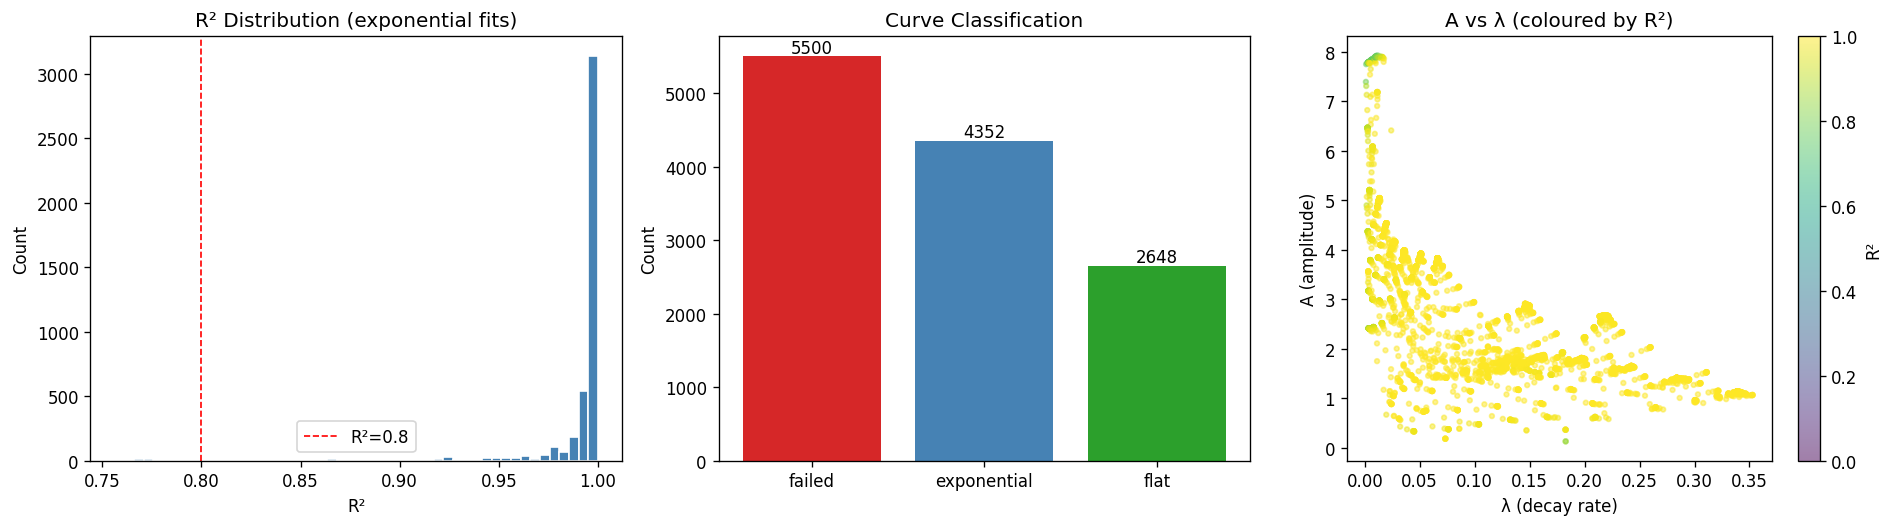

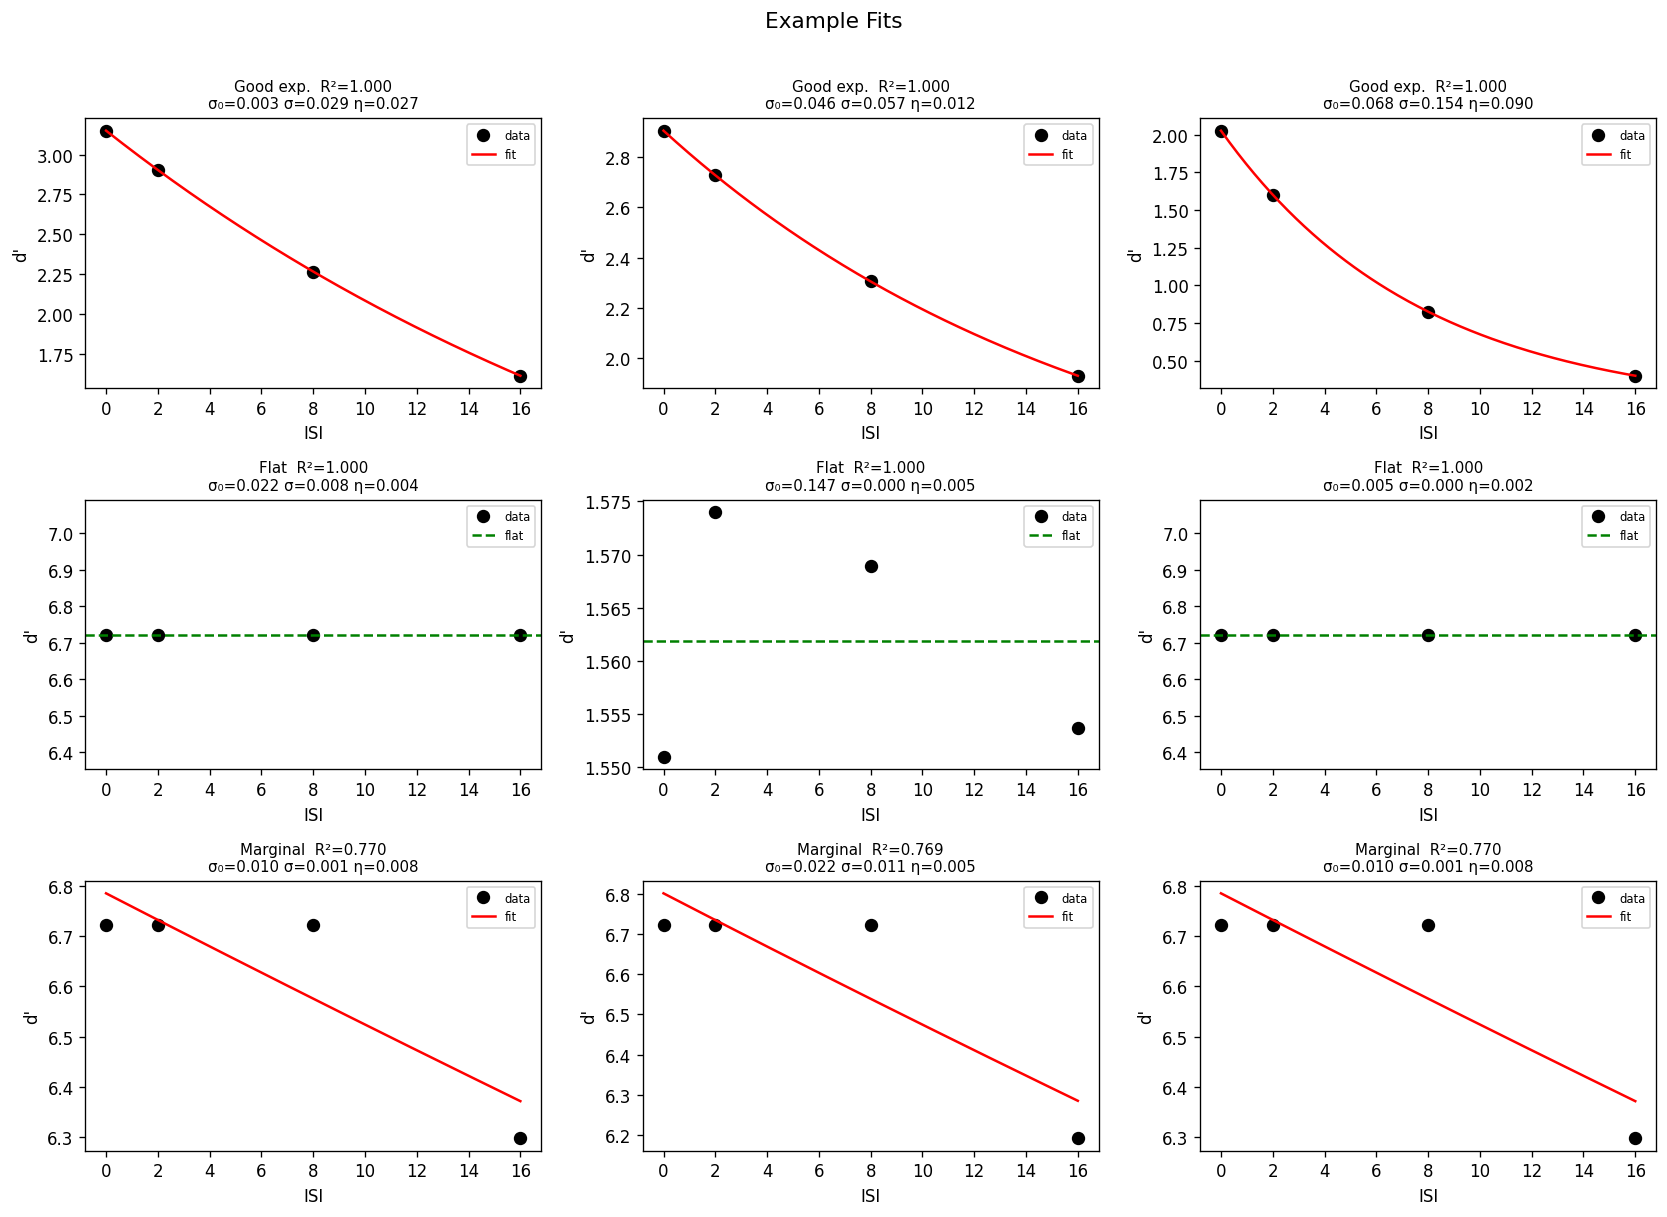

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. R² histogram (exponential fits only)
ax = axes[0]
r2_vals = df.loc[exp_mask, 'R2']
ax.hist(r2_vals, bins=50, color='steelblue', edgecolor='white')
ax.axvline(0.8, color='red', linestyle='--', linewidth=1, label='R²=0.8')
ax.set_xlabel('R²')
ax.set_ylabel('Count')
ax.set_title('R² Distribution (exponential fits)')
ax.legend()

# 2. Curve-type bar chart
ax = axes[1]
counts = df['curve_type'].value_counts()
colors = {'exponential': 'steelblue', 'flat': '#2ca02c', 'failed': '#d62728'}
ax.bar(counts.index, counts.values,
       color=[colors.get(c, 'gray') for c in counts.index])
ax.set_ylabel('Count')
ax.set_title('Curve Classification')
for i, (ct, n) in enumerate(counts.items()):
    ax.text(i, n + 50, str(n), ha='center', fontsize=10)

# 3. A vs λ scatter coloured by R²
ax = axes[2]
exp_df = df[exp_mask]
sc = ax.scatter(exp_df['lam'], exp_df['A'], c=exp_df['R2'],
                cmap='viridis', s=8, alpha=0.5, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='R²')
ax.set_xlabel('λ (decay rate)')
ax.set_ylabel('A (amplitude)')
ax.set_title('A vs λ (coloured by R²)')

fig.tight_layout()
plt.show()

# ── Example fits: 3 good exponential, 3 flat, 3 low-R² ──
isi_fine = np.linspace(0, 16, 200)

good = exp_df.nlargest(3, 'R2')
flat_df = df[df['curve_type'] == 'flat'].sample(n=min(3, (df['curve_type']=='flat').sum()),
                                                 random_state=42)
marginal = exp_df[(exp_df['R2'] > 0.3) & (exp_df['R2'] < 0.85)].sample(
    n=min(3, len(exp_df)), random_state=42)
examples = pd.concat([good, flat_df, marginal]).reset_index(drop=True)
labels = (['Good exp.'] * len(good) + ['Flat'] * len(flat_df)
          + ['Marginal'] * len(marginal))

fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharey=False)
for idx, (ax, (_, row), lab) in enumerate(zip(axes.flat, examples.iterrows(), labels)):
    dp = [row[f'dprime_isi{isi}'] for isi in ISI_VALUES]
    ax.plot(isi_arr, dp, 'ko', markersize=7, label='data')
    if row['curve_type'] == 'exponential' and not np.isnan(row['A']):
        ax.plot(isi_fine, exp_decay(isi_fine, row['A'], row['lam'], row['C']),
                'r-', linewidth=1.5, label='fit')
    elif row['curve_type'] == 'flat':
        ax.axhline(row['C'], color='green', linestyle='--', label='flat')
    ax.set_title(f'{lab}  R²={row["R2"]:.3f}\n'
                 f'σ₀={row["sigma0"]:.3f} σ={row["sigma"]:.3f} η={row["eta"]:.3f}',
                 fontsize=9)
    ax.set_xlabel('ISI')
    ax.set_ylabel("d'")
    ax.legend(fontsize=7)

fig.suptitle('Example Fits', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## θ_f Scatter Plots: σ vs η at Representative σ₀ Slices

For each of 4 representative σ₀ values (min, Q1, Q3, max), we plot the full
(σ, η) grid as a scatter plot.  Each point is coloured by a component of
θ_f — revealing how the drift parameters (σ, η) shape the decay curve at
different levels of encoding noise.

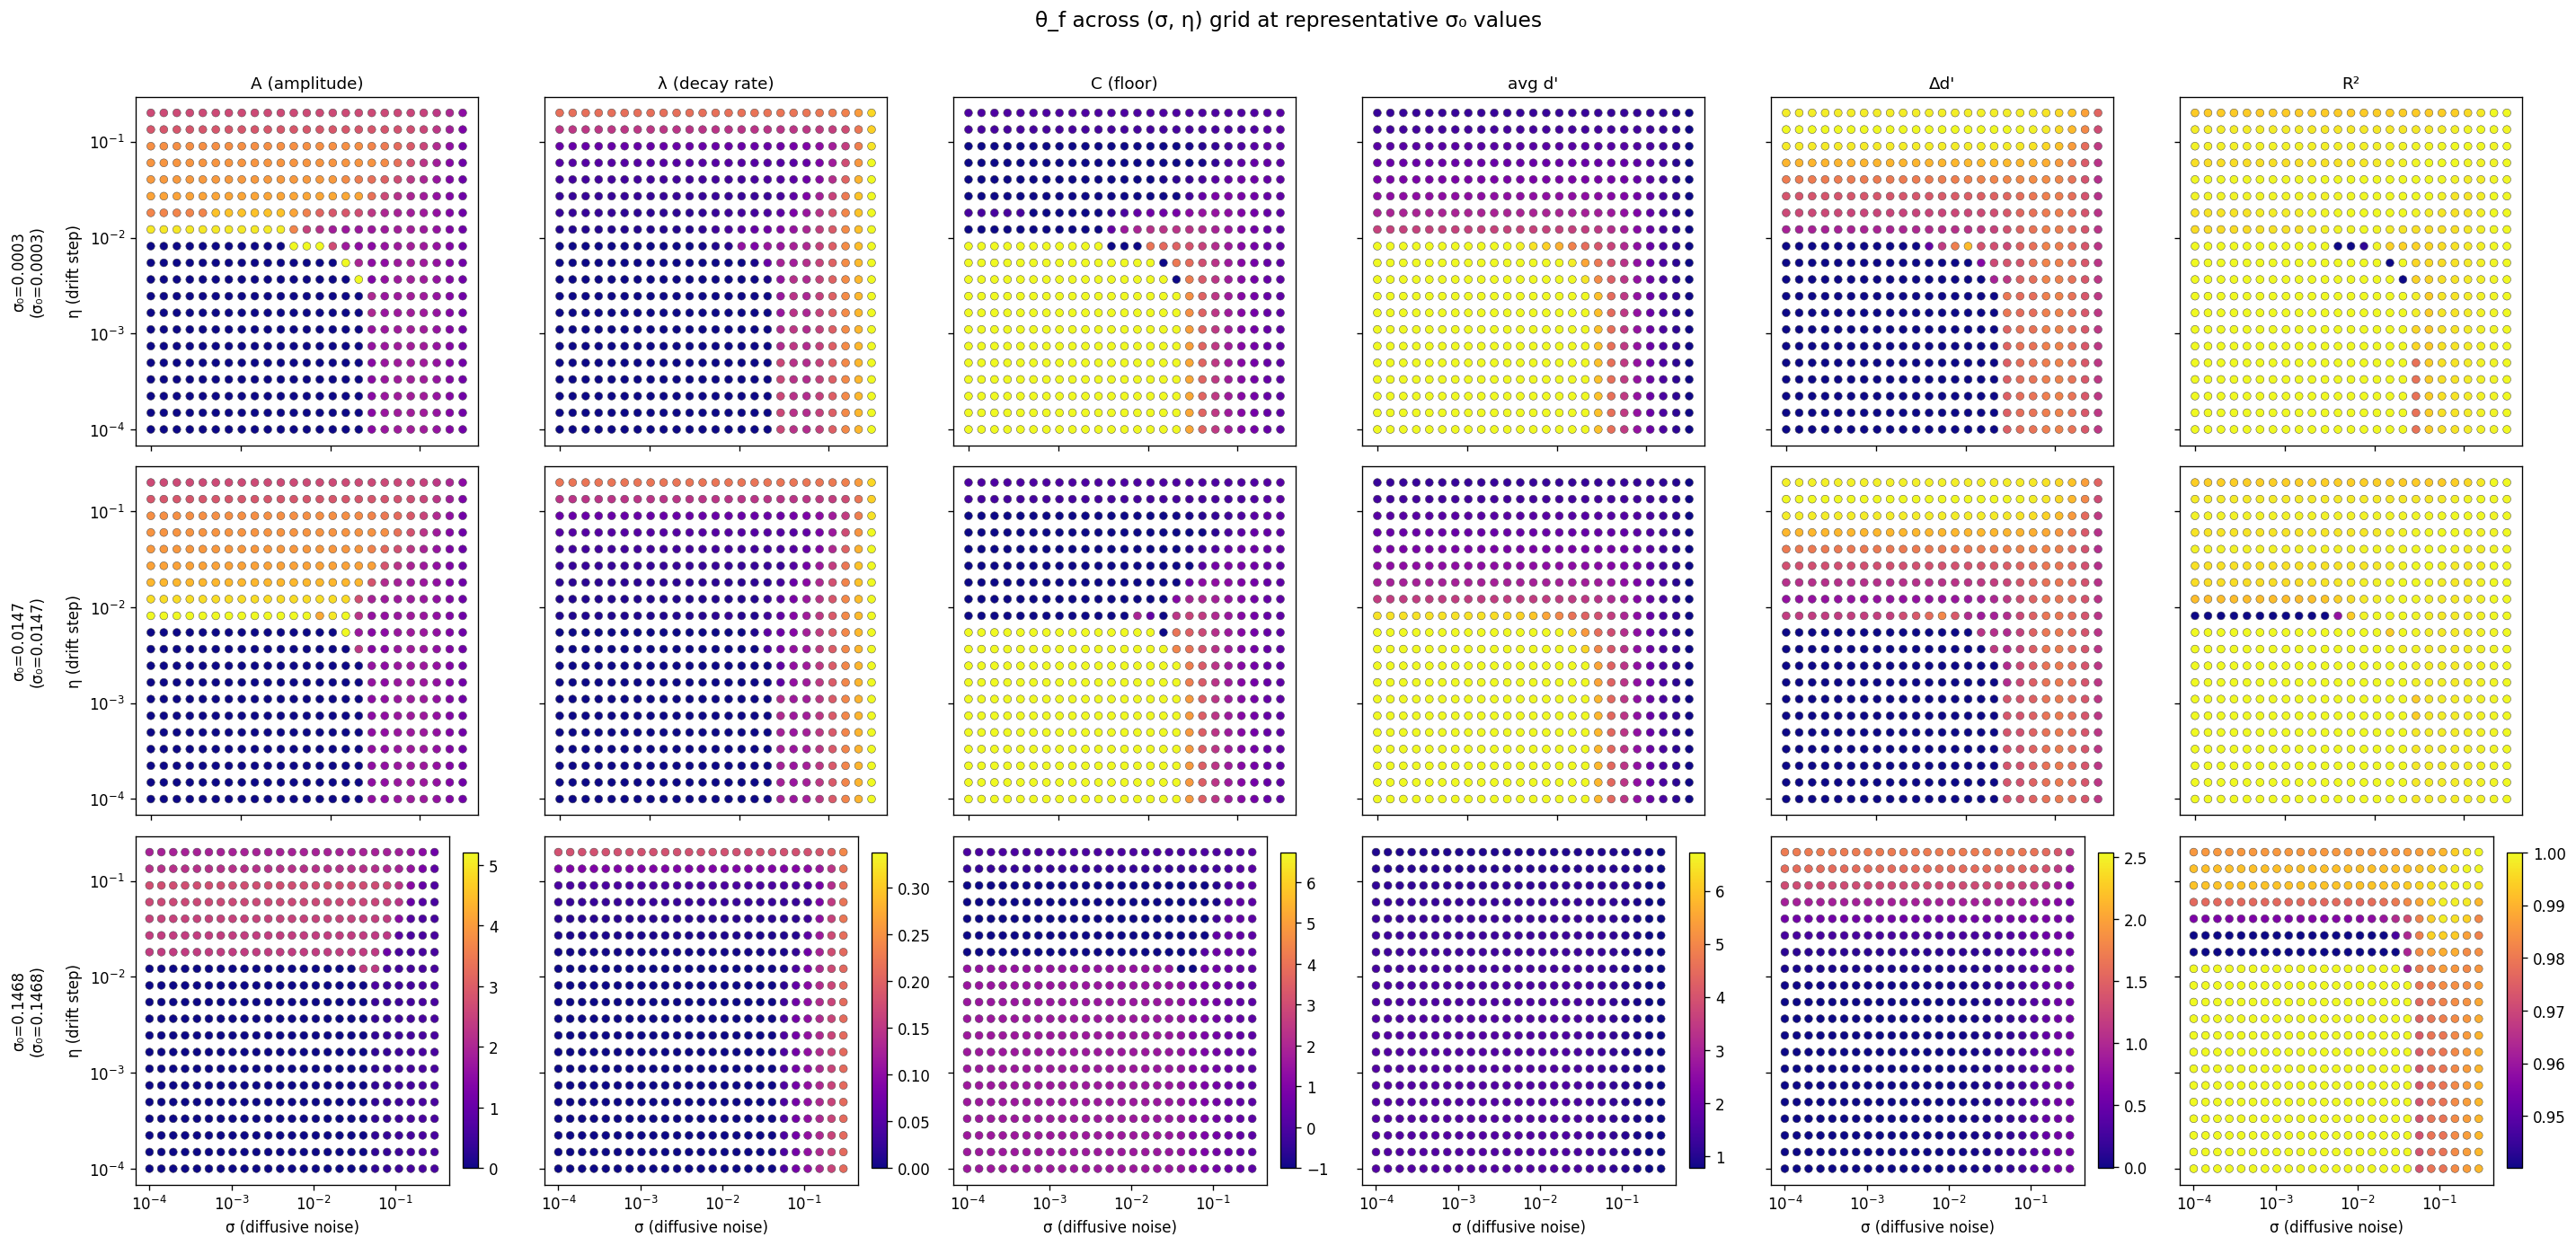

In [9]:
# Pick σ₀ slices where the grid is "interesting" (≥20% exponential fits)
exp_frac_per_s0 = df.groupby('i_s0')['curve_type'].apply(lambda x: (x == 'exponential').mean())
interesting = exp_frac_per_s0[exp_frac_per_s0 >= 0.2].index.values

# Take first, middle, last of the interesting range
s0_indices = [interesting[0], interesting[len(interesting) // 2], interesting[-1]]
s0_labels = [f'σ₀={sigma0_grid[i]:.4f}' for i in s0_indices]



# θ_f quantities to visualise
theta_f_cols = ['A', 'lam', 'C', 'avg_dprime', 'delta_dprime', 'R2']
theta_f_labels = ['A (amplitude)', 'λ (decay rate)', 'C (floor)',
                  'avg d\'', 'Δd\'', 'R²']

# Precompute global colour ranges per quantity (shared across σ₀ rows)
vranges = {}
for col in theta_f_cols:
    vals = df[col].dropna()
    vranges[col] = (vals.quantile(0.02), vals.quantile(0.98))

fig, axes = plt.subplots(len(s0_indices), len(theta_f_cols),
                         figsize=(4 * len(theta_f_cols),
                                  3.8 * len(s0_indices)))

for row, (i_s0, s0_lab) in enumerate(zip(s0_indices, s0_labels)):
    sub = df[df['i_s0'] == i_s0]
    s0_val = sigma0_grid[i_s0]

    for col_idx, (col, clab) in enumerate(zip(theta_f_cols, theta_f_labels)):
        ax = axes[row, col_idx]
        vmin, vmax = vranges[col]

        # Use symlog to handle σ=0 and η=0 grid points
        sc = ax.scatter(sub['sigma'], sub['eta'],
                        c=sub[col], cmap='plasma',
                        s=28, edgecolors='0.3', linewidths=0.3,
                        vmin=vmin, vmax=vmax)

        ax.set_xscale('symlog', linthresh=sigma_grid[sigma_grid > 0].min())
        ax.set_yscale('symlog', linthresh=eta_grid[eta_grid > 0].min())

        if row == len(s0_indices) - 1:
            ax.set_xlabel('σ (diffusive noise)')
        else:
            ax.set_xticklabels([])

        if col_idx == 0:
            ax.set_ylabel(f'σ₀={s0_val:.4f}\n({s0_lab})\n\nη (drift step)')
        else:
            ax.set_yticklabels([])

        if row == 0:
            ax.set_title(clab, fontsize=11)

        if row == len(s0_indices) - 1:
            plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('θ_f across (σ, η) grid at representative σ₀ values',
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()
